<a href="https://colab.research.google.com/github/CatherineMatangu/MyRepo_2026_Analytics2/blob/main/Clustering.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>


--- Generating synthetic agricultural data: kenya_agricultural_data.csv ---
Synthetic dataset 'kenya_agricultural_data.csv' generated successfully.

--- Loading Dataset into Spark ---
Schema of loaded data:
root
 |-- County: string (nullable = true)
 |-- Rainfall_mm: double (nullable = true)
 |-- Soil_pH: double (nullable = true)
 |-- Soil_Nitrogen_pct: double (nullable = true)
 |-- Soil_Organic_Matter_pct: double (nullable = true)

First 5 rows of loaded data:
+-----------+------------------+-----------------+-------------------+-----------------------+
|     County|       Rainfall_mm|          Soil_pH|  Soil_Nitrogen_pct|Soil_Organic_Matter_pct|
+-----------+------------------+-----------------+-------------------+-----------------------+
|     Kiambu|1218.3845460477614| 5.54795829514539|0.25739023021759283|      4.390462435117821|
|      Nyeri| 1308.698533131794|5.232495140126223|0.28374537759170326|      5.043934402908883|
|"Murang""a"|1449.6093063954065|5.397249430575425| 0.25250

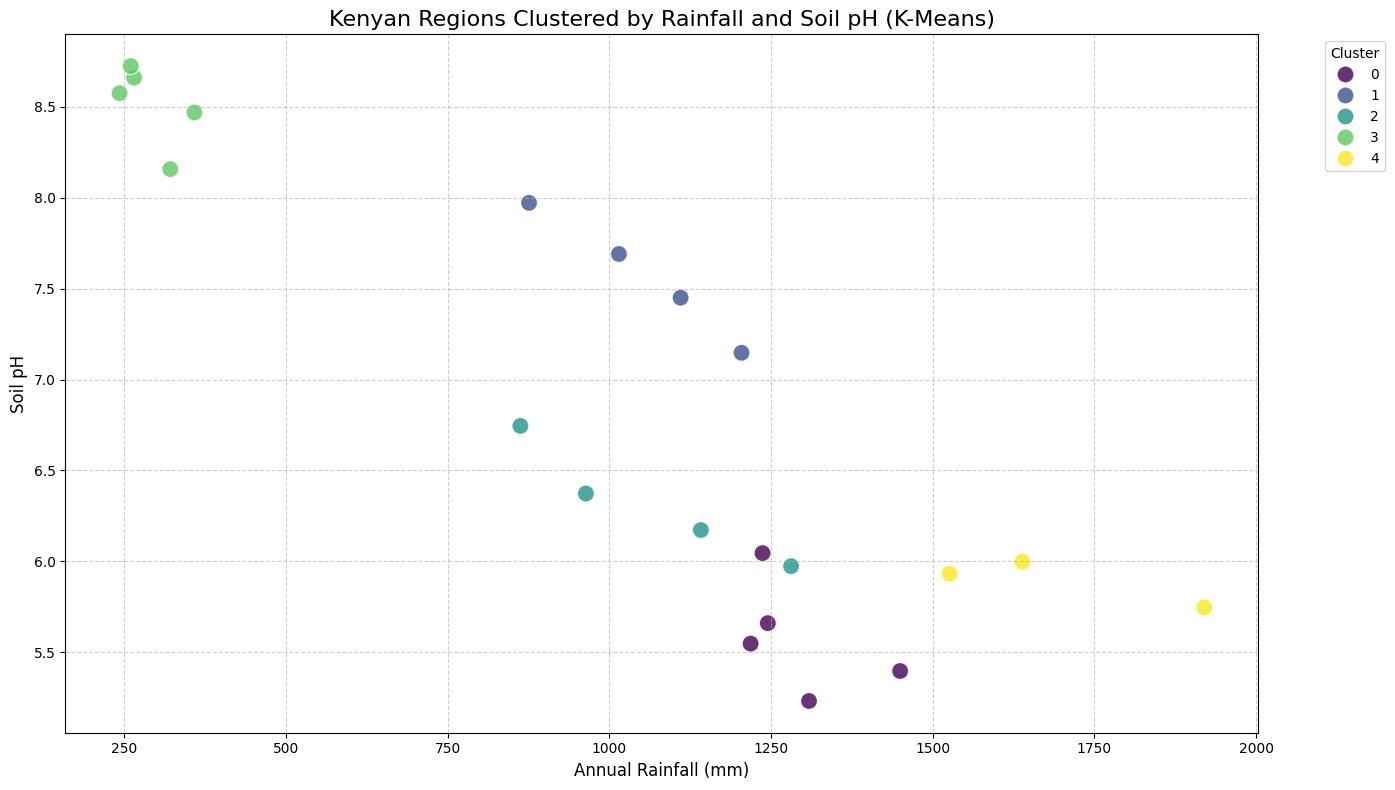

Visualization saved as 'kenya_agri_clusters_kmeans.png'

--- K-Means Cluster Mean Characteristics ---
   prediction  avg(Rainfall_mm)  avg(Soil_pH)  avg(Soil_Nitrogen_pct)  \
0           1           1051.21          7.56                    0.10   
1           3            289.22          8.52                    0.03   
2           4           1694.98          5.89                    0.18   
3           2           1062.10          6.32                    0.18   
4           0           1291.69          5.58                    0.25   

   avg(Soil_Organic_Matter_pct)  
0                          1.32  
1                          0.47  
2                          3.13  
3                          3.32  
4                          4.49  

--- Agricultural Recommendations based on K-Means Clusters ---

--- Recommendations for Cluster 1 ---
  Average Rainfall: 1051 mm, Average Soil pH: 7.6, Average Nitrogen: 0.10%, Average Organic Matter: 1.3%
  - **Characteristics**: Diverse conditions, re

In [1]:
"""
Kenyan Agricultural Regions Clustering: A Spark-based Solution for Jupyter Notebooks

This script provides a complete, self-contained solution for clustering Kenyan regions
based on simulated soil and rainfall characteristics using Apache Spark. It is designed
to run seamlessly within a Jupyter Notebook environment.

It includes:

1.  **Introduction**: Overview of the project and its objectives.
2.  **Setup**: Instructions and commands for installing necessary libraries (PySpark, Java, etc.).
3.  **Data Generation**: Creation of a synthetic dataset representing Kenyan counties with
    soil pH, nitrogen, organic matter, and annual rainfall data.
4.  **Spark Session Initialization**: Setting up the Apache Spark environment, optimized for Jupyter.
5.  **Data Preprocessing**: Feature engineering and scaling using Spark MLlib.
6.  **Clustering Algorithms**: Application of K-Means and Bisecting K-Means clustering.
7.  **Cluster Interpretation and Visualization**: Analysis of cluster characteristics and
    visualization of the results, displayed inline in Jupyter.
8.  **Agricultural Recommendations**: Proposed improvements based on the identified clusters.

"""

# --- 1. Introduction ---
# This project aims to group Kenyan regions (represented by counties in a simulated dataset)
# based on their soil and rainfall characteristics. By identifying distinct agricultural zones,
# tailored recommendations for crop selection and farming practices can be provided.
# The analysis is performed using Apache Spark for scalable data processing.

# --- 2. Setup ---
# To run this script in a Jupyter Notebook, ensure you have Java (OpenJDK 11 or 17 recommended)
# and PySpark installed. If you encounter a NameError or ImportError, uncomment and run the
# following lines in a separate Jupyter cell or your terminal:
#
# !sudo apt-get update
# !sudo apt-get install -y openjdk-17-jdk
# !pip install pyspark pandas matplotlib seaborn numpy findspark
#
# If you encounter issues with JAVA_HOME, you might need to set it manually:
# import os
# os.environ["JAVA_HOME"] = "/usr/lib/jvm/java-17-openjdk-amd64" # Adjust path as necessary
#
# After installing, you might need to restart your Jupyter kernel.

!pip install pyspark findspark
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Try to import PySpark and initialize findspark
try:
    import findspark
    findspark.init()
    from pyspark.sql import SparkSession
    from pyspark.ml.feature import VectorAssembler, StandardScaler
    from pyspark.ml.clustering import KMeans, BisectingKMeans
    from pyspark.ml.evaluation import ClusteringEvaluator
except ImportError:
    print("\nError: PySpark or findspark libraries not found. Please ensure they are installed.")
    print("Refer to the 'Setup' section in the script for installation instructions.")
    sys.exit(1) # Exit if essential libraries are not found

# --- 3. Data Generation ---
def generate_kenya_agricultural_data(filename="kenya_agricultural_data.csv"):
    """
    Generates a synthetic dataset for Kenyan counties with soil and rainfall characteristics.
    This data simulates different agro-ecological zones found in Kenya.
    """
    print(f"\n--- Generating synthetic agricultural data: {filename} ---")
    data = [
        # Central Highlands (High Rainfall, Acidic/Fertile Soil)
        {"County": "Kiambu", "Rainfall_mm": 1200, "Soil_pH": 5.5, "Soil_Nitrogen_pct": 0.25, "Soil_Organic_Matter_pct": 4.5},
        {"County": "Nyeri", "Rainfall_mm": 1350, "Soil_pH": 5.2, "Soil_Nitrogen_pct": 0.28, "Soil_Organic_Matter_pct": 5.0},
        {"County": "Murang\"a", "Rainfall_mm": 1400, "Soil_pH": 5.4, "Soil_Nitrogen_pct": 0.26, "Soil_Organic_Matter_pct": 4.8},
        {"County": "Kirinyaga", "Rainfall_mm": 1250, "Soil_pH": 5.6, "Soil_Nitrogen_pct": 0.24, "Soil_Organic_Matter_pct": 4.2},
        # Rift Valley (Moderate to High Rainfall, Volcanic/Fertile Soil)
        {"County": "Nakuru", "Rainfall_mm": 950, "Soil_pH": 6.5, "Soil_Nitrogen_pct": 0.20, "Soil_Organic_Matter_pct": 3.5},
        {"County": "Uasin Gishu", "Rainfall_mm": 1100, "Soil_pH": 6.2, "Soil_Nitrogen_pct": 0.22, "Soil_Organic_Matter_pct": 3.8},
        {"County": "Trans Nzoia", "Rainfall_mm": 1200, "Soil_pH": 6.0, "Soil_Nitrogen_pct": 0.24, "Soil_Organic_Matter_pct": 4.0},
        {"County": "Narok", "Rainfall_mm": 850, "Soil_pH": 6.8, "Soil_Nitrogen_pct": 0.18, "Soil_Organic_Matter_pct": 3.2},

        # Lake Victoria Basin (High Rainfall, Clay/Alluvial Soil)
        {"County": "Kisumu", "Rainfall_mm": 1300, "Soil_pH": 6.0, "Soil_Nitrogen_pct": 0.15, "Soil_Organic_Matter_pct": 2.5},
        {"County": "Kakamega", "Rainfall_mm": 1900, "Soil_pH": 5.8, "Soil_Nitrogen_pct": 0.20, "Soil_Organic_Matter_pct": 3.5},
        {"County": "Bungoma", "Rainfall_mm": 1500, "Soil_pH": 5.9, "Soil_Nitrogen_pct": 0.18, "Soil_Organic_Matter_pct": 3.0},
        {"County": "Busia", "Rainfall_mm": 1600, "Soil_pH": 6.1, "Soil_Nitrogen_pct": 0.16, "Soil_Organic_Matter_pct": 2.8},

        # Coastal Plain (Moderate Rainfall, Sandy/Saline Soil)
        {"County": "Mombasa", "Rainfall_mm": 1100, "Soil_pH": 7.5, "Soil_Nitrogen_pct": 0.10, "Soil_Organic_Matter_pct": 1.5},
        {"County": "Kilifi", "Rainfall_mm": 1000, "Soil_pH": 7.8, "Soil_Nitrogen_pct": 0.08, "Soil_Organic_Matter_pct": 1.2},
        {"County": "Kwale", "Rainfall_mm": 1200, "Soil_pH": 7.2, "Soil_Nitrogen_pct": 0.12, "Soil_Organic_Matter_pct": 1.8},
        {"County": "Lamu", "Rainfall_mm": 900, "Soil_pH": 8.0, "Soil_Nitrogen_pct": 0.07, "Soil_Organic_Matter_pct": 1.0},

        # Northern Arid (Low Rainfall, Sandy/Rocky/Alkaline Soil)
        {"County": "Turkana", "Rainfall_mm": 250, "Soil_pH": 8.5, "Soil_Nitrogen_pct": 0.03, "Soil_Organic_Matter_pct": 0.5},
        {"County": "Marsabit", "Rainfall_mm": 300, "Soil_pH": 8.2, "Soil_Nitrogen_pct": 0.04, "Soil_Organic_Matter_pct": 0.6},
        {"County": "Garissa", "Rainfall_mm": 350, "Soil_pH": 8.4, "Soil_Nitrogen_pct": 0.03, "Soil_Organic_Matter_pct": 0.4},
        {"County": "Wajir", "Rainfall_mm": 280, "Soil_pH": 8.6, "Soil_Nitrogen_pct": 0.02, "Soil_Organic_Matter_pct": 0.3},
        {"County": "Mandera", "Rainfall_mm": 260, "Soil_pH": 8.7, "Soil_Nitrogen_pct": 0.02, "Soil_Organic_Matter_pct": 0.2},
    ]

    # Add some noise to make it more realistic and prevent perfect separation
    df = pd.DataFrame(data)
    numeric_cols = ["Rainfall_mm", "Soil_pH", "Soil_Nitrogen_pct", "Soil_Organic_Matter_pct"]
    for col in numeric_cols:
        noise = np.random.normal(0, df[col].std() * 0.05, size=len(df)) # 5% standard deviation noise
        df[col] = df[col] + noise

    # Save to CSV
    df.to_csv(filename, index=False)
    print(f"Synthetic dataset \'{filename}\' generated successfully.")
    return filename

# --- Main Execution Block ---
# Generate the dataset first
data_file = generate_kenya_agricultural_data()

# Create SparkSession. Use getOrCreate() for Jupyter to handle existing sessions gracefully.
spark = SparkSession.builder \
    .appName("KenyanAgriClustering") \
    .getOrCreate()

# 1. Load Dataset
print("\n--- Loading Dataset into Spark ---")
df_spark = spark.read.csv(data_file, header=True, inferSchema=True)
print("Schema of loaded data:")
df_spark.printSchema()
print("First 5 rows of loaded data:")
df_spark.show(5)

# 2. Preprocessing
print("\n--- Preprocessing Data for Clustering ---")
# Select features for clustering
feature_cols = ["Rainfall_mm", "Soil_pH", "Soil_Nitrogen_pct", "Soil_Organic_Matter_pct"]

# Assemble features into a single vector
assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
data_vec = assembler.transform(df_spark)

# Scale the features (important for distance-based algorithms like K-Means)
scaler = StandardScaler(inputCol="features", outputCol="scaledFeatures", withStd=True, withMean=True)
scaler_model = scaler.fit(data_vec)
data_final = scaler_model.transform(data_vec)
print("Data after feature assembly and scaling:")
data_final.select("County", "features", "scaledFeatures").show(5, truncate=False)

# 3. Apply Clustering Method 1: K-Means
print("\n--- Running K-Means Clustering ---")
# We choose k=5 based on the typical number of distinct agro-ecological zones in Kenya
kmeans = KMeans(featuresCol="scaledFeatures", k=5, seed=42)
model_kmeans = kmeans.fit(data_final)
predictions_kmeans = model_kmeans.transform(data_final)

# Evaluate K-Means using Silhouette Score
evaluator = ClusteringEvaluator(featuresCol="scaledFeatures")
silhouette_kmeans = evaluator.evaluate(predictions_kmeans)
print(f"K-Means Silhouette Score: {silhouette_kmeans:.4f}")
print("K-Means Cluster Centers:")
for i, center in enumerate(model_kmeans.clusterCenters()):
    print(f"  Cluster {i}: {center}")

# 4. Apply Clustering Method 2: Bisecting K-Means (Hierarchical)
print("\n--- Running Bisecting K-Means Clustering ---")
bkm = BisectingKMeans(featuresCol="scaledFeatures", k=5, seed=42, minDivisibleClusterSize=1.0)
model_bkm = bkm.fit(data_final)
predictions_bkm = model_bkm.transform(data_final)

# Check number of distinct clusters produced by Bisecting K-Means
num_clusters_bkm = predictions_bkm.select("prediction").distinct().count()
print(f"Bisecting K-Means produced {num_clusters_bkm} clusters.")

# Evaluate Bisecting K-Means if more than 1 cluster was formed
if num_clusters_bkm > 1:
    silhouette_bkm = evaluator.evaluate(predictions_bkm)
    print(f"Bisecting K-Means Silhouette Score: {silhouette_bkm:.4f}")
    print("Bisecting K-Means Cluster Centers:")
    for i, center in enumerate(model_bkm.clusterCenters()):
        print(f"  Cluster {i}: {center}")
else:
    print("Bisecting K-Means failed to split into multiple clusters.")

# 5. Interpretation and Visualization
print("\n--- Visualizing and Interpreting Clusters (K-Means Results) ---")
pandas_df_kmeans = predictions_kmeans.select("County", "Rainfall_mm", "Soil_pH", "prediction").toPandas()

plt.figure(figsize=(14, 8))
sns.scatterplot(
    data=pandas_df_kmeans,
    x="Rainfall_mm",
    y="Soil_pH",
    hue="prediction",
    palette="viridis",
    s=150,
    alpha=0.8,
    edgecolor='w'
)
plt.title("Kenyan Regions Clustered by Rainfall and Soil pH (K-Means)", fontsize=16)
plt.xlabel("Annual Rainfall (mm)", fontsize=12)
plt.ylabel("Soil pH", fontsize=12)
plt.legend(title="Cluster", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, linestyle='--', alpha=0.6)
plt.tight_layout()
plot_filename = "kenya_agri_clusters_kmeans.png"
plt.savefig(plot_filename)
plt.show()
print(f"Visualization saved as \'{plot_filename}\'")

# Analyze Cluster Characteristics (Mean values for each feature within each K-Means cluster)
print("\n--- K-Means Cluster Mean Characteristics ---")
cluster_summary_kmeans = predictions_kmeans.groupBy("prediction").mean(*feature_cols).toPandas()
print(cluster_summary_kmeans.round(2))

# 6. Propose Agricultural Improvements
print("\n--- Agricultural Recommendations based on K-Means Clusters ---")
for index, row in cluster_summary_kmeans.iterrows():
    cluster_id = int(row["prediction"])
    rainfall = row["avg(Rainfall_mm)"]
    ph = row["avg(Soil_pH)"]
    nitrogen = row["avg(Soil_Nitrogen_pct)"]
    organic_matter = row["avg(Soil_Organic_Matter_pct)"]

    print(f"\n--- Recommendations for Cluster {cluster_id} ---")
    print(f"  Average Rainfall: {rainfall:.0f} mm, Average Soil pH: {ph:.1f}, Average Nitrogen: {nitrogen:.2f}%, Average Organic Matter: {organic_matter:.1f}%")

    if rainfall < 500 and ph > 7.5:
        print("  - **Characteristics**: Arid/Semi-Arid, Alkaline soils. (e.g., Northern Arid regions)")
        print("  - **Improvements**: Focus on drought-resistant crops (sorghum, millet, indigenous vegetables), implement water harvesting techniques, and consider saline-tolerant crops.")
    elif 500 <= rainfall < 1000 and 6.0 <= ph <= 7.5:
        print("  - **Characteristics**: Semi-Arid to Moderate Rainfall, Neutral to Slightly Alkaline soils.")
        print("  - **Improvements**: Promote water-efficient irrigation, introduce drought-tolerant cash crops (cotton, sunflower), and improve soil structure with organic fertilizers.")
    elif 1000 <= rainfall < 1500 and 5.0 <= ph < 6.5:
        print("  - **Characteristics**: Moderate to High Rainfall, Slightly Acidic to Neutral soils.")
        print("  - **Improvements**: Suitable for maize, beans, potatoes, and horticulture. Optimize fertilizer application based on soil testing. Implement terracing to prevent erosion.")
    elif rainfall >= 1500 and ph < 6.0:
        print("  - **Characteristics**: High Rainfall, Acidic soils.")
        print("  - **Improvements**: Ideal for tea, coffee, and dairy farming. Apply agricultural lime to raise soil pH. Implement robust drainage systems.")
    else:
        print("  - **Characteristics**: Diverse conditions, requires specific local assessment.")
        print("  - **Improvements**: Conduct detailed local soil analysis. Implement diversified farming systems. Explore niche crops for specific micro-climates.")

# Stop Spark Session
spark.stop()
print("\nSpark Session stopped.")